In [1]:
import sys
sys.path.append("..")

import pandas as pd

from utils import normalize_items, outlet_features, build_panel, calendar_features, outlier_handling, prepare_forecast_data

### 1. Load & normalize items
Termasuk exclude/rename item ber-prefix `xxx.` (lihat `normalize_items.EXCLUDED_ITEMS`, `EXPLICIT_ITEM_RENAMES`) — status: penanganan kode sudah ada, tapi belum dikonfirmasi ke data owner (todo list blocker #2).

In [2]:
normalized = normalize_items.load_and_normalize()

print(normalized.shape)
normalized.head()

(692993, 7)


,Kode Barang,Tanggal,Nama Cabang,Kuantitas,Kategori Barang,Nama Barang,Satuan
0,FGS-00001,2024-01-01,KY001 - Kebuli Yaman Kutabumi (Pusat),235.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong
1,FGS-00001,2024-01-01,KY002 - Kebuli Yaman Cilegon,168.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong
2,FGS-00001,2024-01-01,KY003 - Kebuli Yaman Serang,84.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong
3,FGS-00001,2024-01-01,KY004 - Kebuli Yaman Depok Sawangan,60.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong
4,FGS-00001,2024-01-01,KY005 - Kebuli Yaman Pandeglang,121.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong


**Contoh data yang butuh keputusan — item ber-prefix `xxx.`**
Sel di bawah menampilkan baris mentah (sebelum exclude/rename) untuk kode yang sudah ditangani `normalize_items.EXCLUDED_ITEMS`/`EXPLICIT_ITEM_RENAMES`, plus satu pembanding (`xxx.FGS.00068`) yang auto-merge tanpa aturan eksplisit karena namanya sudah identik dengan versi non-prefix. Tujuannya menunjukkan kenapa blocker #2 di todo list masih terbuka: keputusan exclude/rename yang ada sekarang bersifat asumsi penulis kode, belum dikonfirmasi data owner.

In [3]:
raw = pd.read_csv(normalize_items.RAW_DATA_FILE, sep=";", encoding="utf-8-sig")
raw["Tanggal"] = pd.to_datetime(raw["Tanggal"], format=normalize_items.DATE_FORMAT)

print("--- Saat ini DI-DROP oleh EXCLUDED_ITEMS ---")
excluded_rows = raw[raw["Kode Barang"].isin(normalize_items.EXCLUDED_ITEMS)]
display(excluded_rows.groupby(["Kode Barang", "Nama Barang"]).agg(
    n_baris=("Kuantitas", "size"), min_qty=("Kuantitas", "min"),
    max_qty=("Kuantitas", "max"), total_qty=("Kuantitas", "sum"),
))
display(excluded_rows.sort_values("Kuantitas", ascending=False).head(3))

print("\n--- Saat ini DI-RENAME oleh EXPLICIT_ITEM_RENAMES (xxx.FGS.00067 -> FGS-00068) ---")
renamed_rows = raw[raw["Kode Barang"] == "xxx.FGS.00067"]
display(renamed_rows.sort_values("Kuantitas", ascending=False).head(3))

print("--- Pembanding: xxx.FGS.00068 (auto-merge ke FGS-00068 tanpa aturan eksplisit, nama sudah identik) ---")
print("Catatan: xxx.FGS.00067 bernama 'Ayam Crispy Original - FG' tapi di-rename manual ke SKU")
print("'FGS-00068 / Ayam Crispy Spicy - FG' -- dua rasa berbeda digabung jadi satu SKU.")
print("Ini keputusan manual yang belum eksplisit dikonfirmasi ke data owner.")
comparison_rows = raw[raw["Kode Barang"] == "xxx.FGS.00068"]
display(comparison_rows.sort_values("Kuantitas", ascending=False).head(3))

--- Saat ini DI-DROP oleh EXCLUDED_ITEMS ---


,,n_baris,min_qty,max_qty,total_qty
Kode Barang,Nama Barang,,,,
xxx.FGS.00066,xxx.Nasi Putih,21,200.0,1600.0,9200.0
xxx.FGS.00069,xxx.Cendol Pandan - FG,74,125.0,5250.0,55500.0
xxx.FGS.00070,xxx.Santan Cendol - FG,74,40.0,1680.0,17760.0
xxx.FGS.00071,xxx.Gula Cendol - FG,74,30.0,1260.0,13320.0


,Tanggal,Kategori Barang,Kode Barang,Nama Barang,Nama Cabang,Satuan,Kuantitas
320563,2025-01-25,Barang Jadi (FG),xxx.FGS.00069,xxx.Cendol Pandan - FG,KY006 - Kebuli Yaman Depok Sentosa,Gr,5250.0
322331,2025-01-27,Barang Jadi (FG),xxx.FGS.00069,xxx.Cendol Pandan - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Gr,2625.0
320024,2025-01-25,Barang Jadi (FG),xxx.FGS.00069,xxx.Cendol Pandan - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Gr,2500.0



--- Saat ini DI-RENAME oleh EXPLICIT_ITEM_RENAMES (xxx.FGS.00067 -> FGS-00068) ---


,Tanggal,Kategori Barang,Kode Barang,Nama Barang,Nama Cabang,Satuan,Kuantitas
523644,2025-07-31,Barang Jadi (FG),xxx.FGS.00067,xxx.Ayam Crispy Original - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Potong,11.0
328409,2025-02-02,Barang Jadi (FG),xxx.FGS.00067,xxx.Ayam Crispy Original - FG,KY041 - Kebuli Yaman Sepatan,Potong,10.0
348872,2025-02-23,Barang Jadi (FG),xxx.FGS.00067,xxx.Ayam Crispy Original - FG,KY041 - Kebuli Yaman Sepatan,Potong,10.0


--- Pembanding: xxx.FGS.00068 (auto-merge ke FGS-00068 tanpa aturan eksplisit, nama sudah identik) ---
Catatan: xxx.FGS.00067 bernama 'Ayam Crispy Original - FG' tapi di-rename manual ke SKU
'FGS-00068 / Ayam Crispy Spicy - FG' -- dua rasa berbeda digabung jadi satu SKU.
Ini keputusan manual yang belum eksplisit dikonfirmasi ke data owner.


,Tanggal,Kategori Barang,Kode Barang,Nama Barang,Nama Cabang,Satuan,Kuantitas
311333,2025-01-15,Barang Jadi (FG),xxx.FGS.00068,xxx.Ayam Crispy Spicy - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Potong,12.0
363789,2025-03-09,Barang Jadi (FG),xxx.FGS.00068,xxx.Ayam Crispy Spicy - FG,KY042 - Kebuli Yaman Batavia,Potong,11.0
524579,2025-07-31,Barang Jadi (FG),xxx.FGS.00068,xxx.Ayam Crispy Spicy - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Potong,9.0


**Outlier Kuantitas ekstrem — full row (hari, outlet, barang)**
Top-20 baris Kuantitas tertinggi di seluruh `dataset.csv` mentah (lihat todo list bagian sanity-check). Kolom `is_xxx_prefix` menandai baris yang beririsan dengan keputusan `xxx.` di atas — banyak outlier ekstrem justru berasal dari item yang statusnya belum jelas, dan beberapa dalam satuan `Gr` (gram) bukan `Potong`/`Porsi`, jadi angka besar tidak otomatis berarti anomali kuantitas fisik.

In [4]:
raw["is_xxx_prefix"] = raw["Kode Barang"].str.startswith("xxx.", na=False)

cols = ["Tanggal", "Kode Barang", "Nama Barang", "Nama Cabang", "Kategori Barang", "Satuan", "Kuantitas", "is_xxx_prefix"]
top20_outliers = raw.sort_values("Kuantitas", ascending=False).head(20)[cols]

print(f"{top20_outliers['is_xxx_prefix'].sum()} dari 20 outlier teratas adalah item ber-prefix xxx.")
top20_outliers

13 dari 20 outlier teratas adalah item ber-prefix xxx.


,Tanggal,Kode Barang,Nama Barang,Nama Cabang,Kategori Barang,Satuan,Kuantitas,is_xxx_prefix
320563,2025-01-25,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY006 - Kebuli Yaman Depok Sentosa,Barang Jadi (FG),Gr,5250.0,True
322331,2025-01-27,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Barang Jadi (FG),Gr,2625.0,True
320024,2025-01-25,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Barang Jadi (FG),Gr,2500.0,True
321740,2025-01-26,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY042 - Kebuli Yaman Batavia,Barang Jadi (FG),Gr,2250.0,True
325166,2025-01-30,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY006 - Kebuli Yaman Depok Sentosa,Barang Jadi (FG),Gr,2000.0,True
325209,2025-01-30,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Barang Jadi (FG),Gr,2000.0,True
321466,2025-01-26,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Barang Jadi (FG),Gr,2000.0,True
320323,2025-01-25,xxx.FGS.00070,xxx.Santan Cendol - FG,KY006 - Kebuli Yaman Depok Sentosa,Barang Jadi (FG),Gr,1680.0,True
328643,2025-02-02,xxx.FGS.00066,xxx.Nasi Putih,KY041 - Kebuli Yaman Sepatan,Barang Jadi (FG),Gr,1600.0,True
331949,2025-02-06,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY006 - Kebuli Yaman Depok Sentosa,Barang Jadi (FG),Gr,1500.0,True


**Cek terbuka — blocker #5 (belum ada keputusan):** `reaggregate_daily` di bawah memakai `Kategori Barang: "first"`, yang diam-diam memilih kategori pertama kalau satu SKU pernah tercatat di lebih dari satu kategori (temuan `eda.ipynb` §2: 27/109 SKU). Sel berikut hanya menampilkan daftarnya sebagai pengingat, tidak mengubah perilaku pipeline.

In [5]:
categories_per_sku = normalized.groupby("Kode Barang")["Kategori Barang"].nunique()
multi_category_skus = categories_per_sku[categories_per_sku > 1]

print(f"{len(multi_category_skus)} dari {categories_per_sku.shape[0]} SKU tercatat di lebih dari satu Kategori Barang")
normalized[normalized["Kode Barang"].isin(multi_category_skus.index)].groupby("Kode Barang")["Kategori Barang"].unique()

0 dari 90 SKU tercatat di lebih dari satu Kategori Barang


Series([], Name: Kategori Barang, dtype: object)

### 2. Outlet matching, canonicalization & region features
Filter cabang yang tidak ada di `outlets.csv` (dianggap sudah tidak beroperasi), kanonikalisasi nama cabang, lalu join `kawasan`/`hari_pengiriman` dari `dataset/outlet_mapping.csv` (blocker #1 — sudah selesai). `lead_time_days` dihitung per baris dari kombinasi (hari-dalam-minggu transaksi, `hari_pengiriman`) via `outlet_features.compute_lead_time_days` — bukan konstanta flat lagi (join & perhitungan aktualnya terjadi di §7, sel ini baru memuat `region_df`).

In [6]:
outlets_df = outlet_features.load_outlets()
overrides_df = outlet_features.load_overrides()
region_df = outlet_features.load_region_mapping()

dropped_branches = set(normalized["Nama Cabang"].unique()) - {
    b for b in normalized["Nama Cabang"].unique()
    if outlet_features.match_branch_to_outlet(b, outlets_df, overrides_df)[0] is not None
}
print(f"{len(dropped_branches)} cabang di-drop (tidak ada di outlets.csv): {sorted(dropped_branches)}")

matched = outlet_features.filter_matched_branches(normalized, outlets_df, overrides_df)
canonical = outlet_features.canonicalize_branch_names(matched, outlets_df, overrides_df)

# Catatan: kawasan/hari_pengiriman/lead_time_days baru di-join lewat apply_region_features
# nanti setelah panel dibangun (§7) — reaggregate_daily & build_dense_panel di bawah hanya
# mempertahankan kolom di AGG_SPEC/CARRY_COLS, jadi kolom region akan hilang kalau di-join di sini.
print(canonical.shape)
canonical.head()

10 cabang di-drop (tidak ada di outlets.csv): ['KY020 - Kebuli Yaman Tambun', 'KY028 - Kebuli Yaman Condet', 'KY035 - Kebuli Yaman Antapani', 'KY046 - Kebuli Yaman Aryana Karawaci', 'KY047 - Kebuli Yaman Ciomas', 'KY052 - Kebuli Yaman Bantarjati Bogor', 'KY055 - Kebuli Yaman Ciputat Timur', 'KY059 - Kebuli Yaman Dukuh Zamrud', 'KY071 - Kebuli Yaman Citayam', 'KY072 - Kebuli Yaman Bintara']


(624142, 7)


,Kode Barang,Tanggal,Nama Cabang,Kuantitas,Kategori Barang,Nama Barang,Satuan
0,FGS-00001,2024-01-01,KY001 - Kebuli Yaman Kutabumi (Pusat),235.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong
1,FGS-00001,2024-01-01,KY002 - Kebuli Yaman Cilegon,168.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong
2,FGS-00001,2024-01-01,KY003 - Kebuli Yaman Serang,84.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong
3,FGS-00001,2024-01-01,KY004 - Kebuli Yaman Depok Sawangan,60.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong
4,FGS-00001,2024-01-01,KY005 - Kebuli Yaman Pandeglang,121.0,Barang Jadi (FG),Ayam Kebuli (0.9),Potong


**Cek terbuka — blocker #3 (belum ada keputusan):** completeness tanggal per cabang terhadap rentang penuh 2024-01-01 s/d 2025-12-31. Todo list menandai KY056 (92.3%) di bawah threshold 95% — sel ini menampilkan ulang semua cabang di bawah threshold agar mudah dibawa ke data owner, tidak men-drop apa pun.

In [7]:
full_range = pd.date_range("2024-01-01", "2025-12-31", freq="D")
days_present = canonical.groupby("Nama Cabang")["Tanggal"].nunique()
completeness = (days_present / len(full_range)).sort_values()

below_threshold = completeness[completeness < 0.95]
print(f"{len(below_threshold)} cabang di bawah threshold completeness 95%:")
below_threshold

18 cabang di bawah threshold completeness 95%:


Nama Cabang
Kebuli Yaman Cilebut                       0.017784
Kebuli Yaman Cadas                         0.123119
KY067 - Kebuli Yaman Metland               0.266758
KY066 - Kebuli Yaman Parung                0.266758
KY065 - Kebuli Yaman Sangiang              0.276334
KY011 - Kebuli Yaman Bekasi Galaxy         0.310534
KY064 - Kebuli Yaman Mutiara Garuda        0.333789
KY063 - Kebuli Yaman Kedaung               0.343365
KY062 - Kebuli Yaman Kampung Baru          0.419973
KY061 - Kebuli Yaman Taman Kirana          0.419973
KY060 - Kebuli Yaman Pakuhaji              0.425445
KY058 - Kebuli Yaman Cikande               0.496580
KY057 - Kebuli Yaman Rawalumbu (Bekasi)    0.544460
KY054 - Kebuli Yaman Jagakarsa             0.716826
KY053 - Kebuli Yaman Cimanggu Bogor        0.745554
KY056 - Kebuli Yaman Tigaraksa             0.846785
KY068 - Kebuli Yaman Kramatwatu            0.900137
KY050 - Kebuli Yaman TangCity Mall         0.906977
Name: Tanggal, dtype: float64

### 3. Reaggregate & build dense panel
Reaggregate ke satu baris per (Kode Barang, Tanggal, Nama Cabang), lalu bangun panel harian padat dan buang pair dengan riwayat < `MIN_HISTORY_DAYS` (60 hari).

In [8]:
reaggregated = normalize_items.reaggregate_daily(canonical)
panel = build_panel.build_dense_panel(reaggregated)

panel_before_filter_shape = panel.shape
panel = build_panel.filter_min_history(panel)

print(f"panel sebelum filter min-history: {panel_before_filter_shape}")
print(f"panel setelah filter min-history: {panel.shape}")
panel.head()

panel sebelum filter min-history: (1356209, 6)
panel setelah filter min-history: (1340034, 6)


,Kode Barang,Nama Cabang,Tanggal,Kuantitas,Kategori Barang,Nama Barang
0,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-01,235.0,Barang Jadi (FG),Ayam Kebuli (0.9)
1,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-02,147.0,Barang Jadi (FG),Ayam Kebuli (0.9)
2,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-03,85.0,Barang Jadi (FG),Ayam Kebuli (0.9)
3,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-04,106.0,Barang Jadi (FG),Ayam Kebuli (0.9)
4,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-05,155.0,Barang Jadi (FG),Ayam Kebuli (0.9)


**Cek terbuka — blocker #4 (belum ada keputusan):** breakdown heuristik kenapa pair gagal `MIN_HISTORY_DAYS` — SKU baru (kemunculan pertama SKU di seluruh dataset dekat cutoff), Outlet baru (idem untuk cabang), atau lainnya (kemungkinan data hilang di pair yang SKU & cabangnya sama-sama sudah lama ada). Ini heuristik untuk mempersempit investigasi, bukan keputusan final.

In [9]:
cutoff = build_panel.TEST_START
min_days = build_panel.MIN_HISTORY_DAYS
new_cutoff = cutoff - pd.Timedelta(days=min_days)

pre_cutoff_counts = (
    reaggregated[reaggregated["Tanggal"] < cutoff]
    .groupby(build_panel.PAIR_COLS)
    .size()
    .reset_index(name="pre_cutoff_days")
)
failing_pairs = pre_cutoff_counts[pre_cutoff_counts["pre_cutoff_days"] < min_days].copy()

sku_first_date = reaggregated.groupby("Kode Barang")["Tanggal"].min()
branch_first_date = reaggregated.groupby("Nama Cabang")["Tanggal"].min()
failing_pairs["sku_first_date"] = failing_pairs["Kode Barang"].map(sku_first_date)
failing_pairs["branch_first_date"] = failing_pairs["Nama Cabang"].map(branch_first_date)

def categorize(row):
    if row["sku_first_date"] >= new_cutoff:
        return "SKU baru"
    if row["branch_first_date"] >= new_cutoff:
        return "Outlet baru"
    return "Lainnya (kemungkinan data hilang)"

failing_pairs["kategori"] = failing_pairs.apply(categorize, axis=1)

print(f"{len(failing_pairs)} dari {len(pre_cutoff_counts)} pair gagal MIN_HISTORY_DAYS ({min_days} hari)")
failing_pairs["kategori"].value_counts()

1287 dari 3095 pair gagal MIN_HISTORY_DAYS (60 hari)


kategori
Lainnya (kemungkinan data hilang)    1104
SKU baru                              143
Outlet baru                            40
Name: count, dtype: int64

### 4. Calendar features

In [10]:
calendar_features.check_year_coverage(panel["Tanggal"])
featured = calendar_features.add_calendar_features(panel)

print(featured.shape)
featured.head()

(1340034, 26)


,Kode Barang,Nama Cabang,Tanggal,Kuantitas,Kategori Barang,Nama Barang,day_of_week,day_of_month,month,is_weekend,...,days_until_eid_al_fitr,is_eid_al_adha,days_since_eid_al_adha,days_until_eid_al_adha,is_independence_day,days_since_independence_day,days_until_independence_day,is_new_year,days_since_new_year,days_until_new_year
0,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-01,235.0,Barang Jadi (FG),Ayam Kebuli (0.9),0,1,1,False,...,NaN,False,NaN,NaN,False,NaN,NaN,True,0.0,0.0
1,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-02,147.0,Barang Jadi (FG),Ayam Kebuli (0.9),1,2,1,False,...,NaN,False,NaN,NaN,False,NaN,NaN,False,1.0,NaN
2,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-03,85.0,Barang Jadi (FG),Ayam Kebuli (0.9),2,3,1,False,...,NaN,False,NaN,NaN,False,NaN,NaN,False,2.0,NaN
3,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-04,106.0,Barang Jadi (FG),Ayam Kebuli (0.9),3,4,1,False,...,NaN,False,NaN,NaN,False,NaN,NaN,False,3.0,NaN
4,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-05,155.0,Barang Jadi (FG),Ayam Kebuli (0.9),4,5,1,False,...,NaN,False,NaN,NaN,False,NaN,NaN,False,4.0,NaN


### 5. Outlier handling
`compute_pair_baseline` menghitung median `Kuantitas` per pair (train-only, pre-cutoff, minimal `MIN_PAIR_HISTORY` hari histori) sebagai baseline "normal". `apply_outlier_capping` meng-cap baris dengan rasio >= `SPIKE_RATIO_THRESHOLD` (5x) baseline ke `Kuantitas_capped` — **kecuali** baris tsb jatuh di window event kalender (`is_ramadan`/`is_eid_al_fitr`/`is_eid_al_adha`/`is_independence_day`/`is_new_year`), makanya section ini harus setelah §4 Calendar features, bukan sebelum §3 seperti draf awal di todo list. Lihat `docs/superpowers/specs/2026-08-08-outlier-handling-design.md`. Konsisten dengan `prepare_forecast_data.py::main()`: `Kuantitas` mentah tetap dipakai untuk target (§6), `Kuantitas_capped` dipakai untuk fitur historis (lag/rolling/branch stats) supaya spike ekstrem tidak mendistorsi input model.

In [11]:
pair_baseline = outlier_handling.compute_pair_baseline(featured, cutoff=cutoff)
featured = outlier_handling.apply_outlier_capping(featured, pair_baseline)

n_eligible_pairs = int(pair_baseline["pair_eligible"].sum())
n_spike_rows = int(featured["is_spike"].sum())
in_event_window = featured[outlier_handling.EVENT_FLAG_COLS].any(axis=1)
n_capped_rows = int((featured["is_spike"] & ~in_event_window).sum())

print(f"{n_eligible_pairs} dari {len(pair_baseline)} pair eligible dapat baseline (>= {outlier_handling.MIN_PAIR_HISTORY} hari histori pre-cutoff)")
print(f"{n_spike_rows} baris terdeteksi spike (rasio >= {outlier_handling.SPIKE_RATIO_THRESHOLD}x baseline median)")
print(f"{n_capped_rows} baris benar-benar di-cap; {n_spike_rows - n_capped_rows} spike dikecualikan karena jatuh di event window")

featured.loc[featured["is_spike"], ["Kode Barang", "Nama Cabang", "Tanggal", "Kuantitas", "baseline_ratio", "Kuantitas_capped"]].sort_values("baseline_ratio", ascending=False).head(10)

2065 dari 2636 pair eligible dapat baseline (>= 30 hari histori pre-cutoff)
11718 baris terdeteksi spike (rasio >= 5.0x baseline median)
8507 baris benar-benar di-cap; 3211 spike dikecualikan karena jatuh di event window


,Kode Barang,Nama Cabang,Tanggal,Kuantitas,baseline_ratio,Kuantitas_capped
206177,FGS-00008,KY051 - kebuli Yaman TOD M1 Bandara,2024-03-19,200.0,200.000000,200.0
154267,FGS-00007,KY009 - Kebuli Yaman Cipinang,2024-04-26,169.0,169.000000,5.0
191564,FGS-00008,KY019 - Kebuli Yaman Ciledug,2025-06-03,157.0,157.000000,5.0
1268724,PCG-00030,KY037 - Kebuli Yaman Hankam,2025-10-12,575.0,127.777778,22.5
1266568,PCG-00030,KY032 - Kebuli Yaman Kelapa Dua Karawaci,2025-10-14,802.0,114.571429,35.0
741283,FGS.00053,KY009 - Kebuli Yaman Cipinang,2025-05-23,212.0,106.000000,10.0
751981,FGS.00053,KY045 - Kebuli Yaman Graha Raya,2025-12-23,102.0,102.000000,5.0
1225293,PCG-00027,KY013 - Kebuli Yaman Cileunyi,2025-03-12,300.0,100.000000,300.0
1258846,PCG-00030,KY013 - Kebuli Yaman Cileunyi,2025-08-10,180.0,90.000000,10.0
1258583,PCG-00030,KY013 - Kebuli Yaman Cileunyi,2024-11-20,170.0,85.000000,10.0


### 6. Targets, lag & rolling features
`add_targets` tetap pakai `Kuantitas` mentah (target harus merepresentasikan demand asli, bukan yang sudah di-cap). `add_lag_features`/`add_rolling_features` pakai `Kuantitas_capped` (§5) supaya fitur historis tidak terdistorsi oleh spike ekstrem — konsisten dengan `prepare_forecast_data.py::main()`.

In [12]:
featured = prepare_forecast_data.add_targets(featured)
featured = prepare_forecast_data.add_lag_features(featured, qty_col="Kuantitas_capped")
featured = prepare_forecast_data.add_rolling_features(featured, qty_col="Kuantitas_capped")

print(featured.shape)
featured.head()

(1340034, 49)


,Kode Barang,Nama Cabang,Tanggal,Kuantitas,Kategori Barang,Nama Barang,day_of_week,day_of_month,month,is_weekend,...,lag_7,lag_14,lag_21,lag_28,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14,roll_mean_28,roll_std_28
0,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-01,235.0,Barang Jadi (FG),Ayam Kebuli (0.9),0,1,1,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-02,147.0,Barang Jadi (FG),Ayam Kebuli (0.9),1,2,1,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-03,85.0,Barang Jadi (FG),Ayam Kebuli (0.9),2,3,1,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-04,106.0,Barang Jadi (FG),Ayam Kebuli (0.9),3,4,1,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,FGS-00001,KY001 - Kebuli Yaman Kutabumi (Pusat),2024-01-05,155.0,Barang Jadi (FG),Ayam Kebuli (0.9),4,5,1,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 7. Branch stats, outlet & region/lead-time features
`apply_region_features` join `kawasan`/`hari_pengiriman`, lalu hitung `lead_time_days` per baris (hari sampai pengiriman berikutnya, variabel per kawasan & hari transaksi — lihat `outlet_features.compute_lead_time_days`). `apply_outlet_features` join `kota`/`has_shopee`/`has_gofood`/`has_grabfood`/`can_order_online` (statis per cabang). `add_lead_time_target` lalu menjumlahkan `Kuantitas` mentah pada window (H+1..H+lead_time_days) jadi `target_lead_time_cumulative` — target cumulative-demand-sampai-pengiriman-berikutnya yang jadi tujuan bisnis inti. `compute_branch_stats` pakai `Kuantitas_capped` (train-only, no leakage) — konsisten dengan `prepare_forecast_data.py::main()`.

In [13]:
featured = outlet_features.apply_region_features(featured, region_df)
featured = prepare_forecast_data.apply_outlet_features(featured, outlets_df, overrides_df)
featured = prepare_forecast_data.add_lead_time_target(featured)
branch_stats = prepare_forecast_data.compute_branch_stats(featured, qty_col="Kuantitas_capped")
featured = prepare_forecast_data.apply_branch_stats(featured, branch_stats)
featured = prepare_forecast_data.add_branch_age_days(featured)

print(featured.shape)
featured[["kawasan", "hari_pengiriman", "lead_time_days", "target_lead_time_cumulative"]].head()

(1340034, 62)


,kawasan,hari_pengiriman,lead_time_days,target_lead_time_cumulative
0,1,Senin dan Kamis,3,338.0
1,1,Senin dan Kamis,2,191.0
2,1,Senin dan Kamis,1,106.0
3,1,Senin dan Kamis,4,730.0
4,1,Senin dan Kamis,3,575.0


In [14]:
# QA: setiap baris di panel harus dapat kawasan (tidak ada NaN dari region join)
unmatched_region = featured[featured["kawasan"].isna()]["Nama Cabang"].unique()
assert len(unmatched_region) == 0, f"Cabang tanpa kawasan: {unmatched_region}"

print(featured.groupby("kawasan")["Nama Cabang"].nunique())
print(featured["lead_time_days"].value_counts())
print(f"target_lead_time_cumulative NaN: {featured['target_lead_time_cumulative'].isna().sum()} dari {len(featured)} baris (boundary akhir Des-2025 + pair tidak eligible)")

kawasan
1    12
2    40
Name: Nama Cabang, dtype: int64
lead_time_days
2    383123
3    383103
1    382806
4    191002
Name: count, dtype: int64
target_lead_time_cumulative NaN: 6143 dari 1340034 baris (boundary akhir Des-2025 + pair tidak eligible)


### 8. QA checks

In [15]:
# Kuantitas non-negatif — lihat catatan CLAUDE.md soal anomali KY011 2024-02-29 (belum dikonfirmasi ulang ke data owner)
assert (featured["Kuantitas"] >= 0).all(), "Ditemukan Kuantitas negatif"

# Tidak ada baris duplikat per (pair, tanggal)
dup_count = featured.duplicated(subset=build_panel.PAIR_COLS + ["Tanggal"]).sum()
assert dup_count == 0, f"Ditemukan {dup_count} baris duplikat (pair, Tanggal)"

print("Kuantitas non-negatif: OK")
print("Tidak ada duplikat (pair, Tanggal): OK")

Kuantitas non-negatif: OK
Tidak ada duplikat (pair, Tanggal): OK


In [16]:
# Outlier-capping QA: Kuantitas_capped tidak pernah melebihi Kuantitas mentah, dan baris yang tidak di-cap harus identik
assert (featured["Kuantitas_capped"] <= featured["Kuantitas"]).all(), "Ditemukan Kuantitas_capped > Kuantitas mentah"

in_event_window = featured[outlier_handling.EVENT_FLAG_COLS].any(axis=1)
should_cap = featured["is_spike"] & ~in_event_window
untouched = ~should_cap
assert (featured.loc[untouched, "Kuantitas_capped"] == featured.loc[untouched, "Kuantitas"]).all(), \
    "Ditemukan baris yang seharusnya tidak di-cap tapi Kuantitas_capped berbeda dari Kuantitas"

print("Outlier-capping QA: OK")
print(f"{int(should_cap.sum())} dari {len(featured)} baris di-cap ke Kuantitas_capped")

Outlier-capping QA: OK
8507 dari 1340034 baris di-cap ke Kuantitas_capped


In [17]:
# Leakage spot-check: lag_1 baris tertentu harus sama dengan Kuantitas H-1 pada pair yang sama
sample = featured[featured["lag_1"].notna()].sample(1, random_state=0).iloc[0]
prior_day = sample["Tanggal"] - pd.Timedelta(days=1)
prior_row = featured[
    (featured["Kode Barang"] == sample["Kode Barang"])
    & (featured["Nama Cabang"] == sample["Nama Cabang"])
    & (featured["Tanggal"] == prior_day)
]
assert not prior_row.empty, "Baris H-1 untuk sample tidak ditemukan"
assert sample["lag_1"] == prior_row.iloc[0]["Kuantitas"], "lag_1 tidak cocok dengan Kuantitas H-1"

print(f"Leakage spot-check OK — pair={sample['Kode Barang']}/{sample['Nama Cabang']}, tanggal={sample['Tanggal'].date()}")

Leakage spot-check OK — pair=PCG-00038/KY007 - Kebuli Yaman Cibubur, tanggal=2025-08-03


In [18]:
# Outlet-match QA: tidak ada cabang "Unknown" (unmatched sudah di-drop di §2)
assert (featured["kota"] != "Unknown").all(), "Ditemukan cabang dengan kota Unknown"

# Setiap Nama Cabang harus map ke tepat satu kota (tidak ada fan-out dari join)
kota_per_branch = featured.groupby("Nama Cabang")["kota"].nunique()
assert (kota_per_branch == 1).all(), "Ditemukan cabang dengan lebih dari satu kota"

print("Outlet-match QA: OK")
print(featured["can_order_online"].value_counts(dropna=False))

Outlet-match QA: OK


can_order_online
True     1324578
False      15456
Name: count, dtype: int64


In [19]:
featured.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340034 entries, 0 to 1340033
Data columns (total 62 columns):
 #   Column                       Non-Null Count    Dtype         
---  ------                       --------------    -----         
 0   Kode Barang                  1340034 non-null  object        
 1   Nama Cabang                  1340034 non-null  object        
 2   Tanggal                      1340034 non-null  datetime64[ns]
 3   Kuantitas                    1340034 non-null  float64       
 4   Kategori Barang              1340034 non-null  object        
 5   Nama Barang                  1340034 non-null  object        
 6   day_of_week                  1340034 non-null  int32         
 7   day_of_month                 1340034 non-null  int32         
 8   month                        1340034 non-null  int32         
 9   is_weekend                   1340034 non-null  bool          
 10  is_national_holiday          1340034 non-null  bool          
 11  is_ramadan 

In [20]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

BLUE = "#2a78d6"
BLUE_DARK = "#173f73"
plt.rcParams.update({
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#dddddd",
    "grid.linewidth": 0.6,
    "font.size": 10,
})

### 9. Visual QA — distribution/outlier & seasonality (vs `eda.ipynb`)
Section ini adalah pengecekan visual pasca-pipeline terhadap `featured`, bukan re-run `eda.ipynb`
(yang mengeksplorasi `dataset.csv` mentah sebelum drop cabang/filter min-history/capping/canonicalize
kategori). Beberapa perbedaan bentuk distribusi/musiman dari `eda.ipynb` **diperkirakan** dan bukan
bug: cabang yang di-drop karena tidak match `outlets.csv` (§2), pair yang gagal `MIN_HISTORY_DAYS`
(§3), kategori yang di-canonicalize ke versi terbaru, dan efek outlier-capping (§5) — tapi bentuk
keseluruhannya harus tetap menyerupai `eda.ipynb`, bukan menyimpang secara struktural.

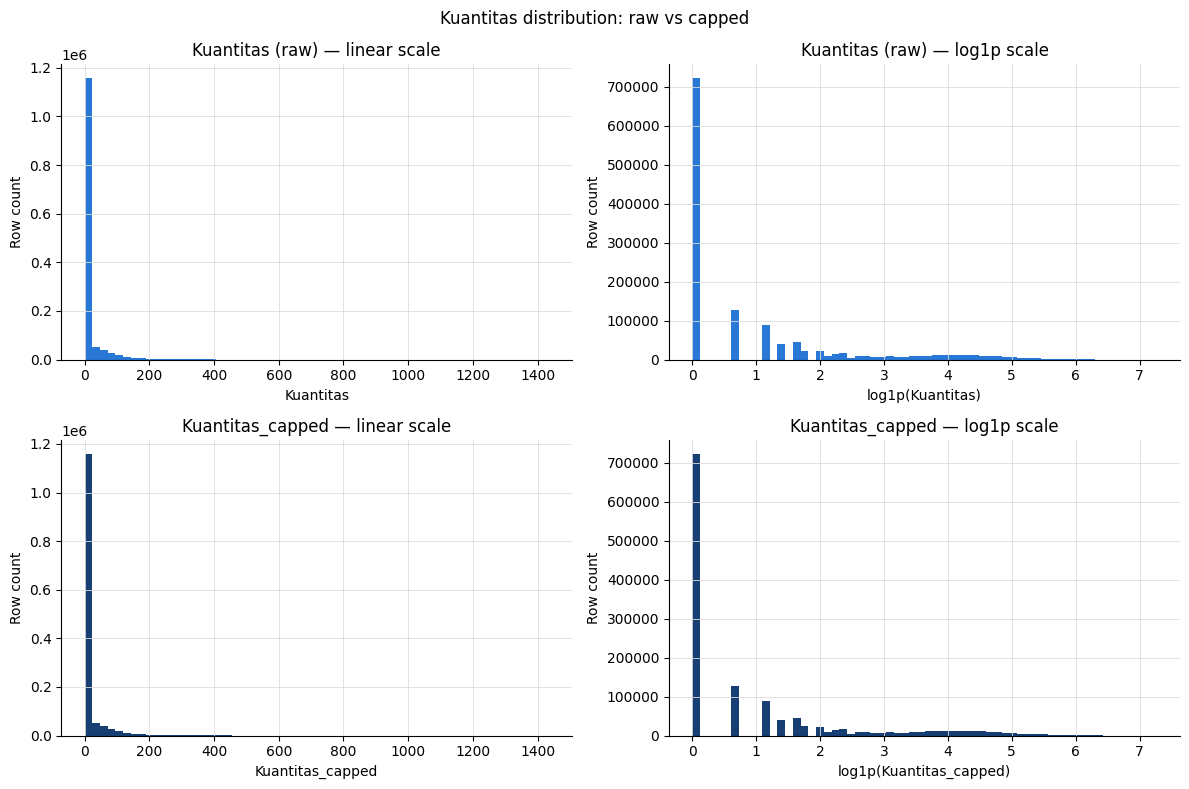

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(featured["Kuantitas"], bins=60, color=BLUE)
axes[0, 0].set_title("Kuantitas (raw) — linear scale")
axes[0, 0].set_xlabel("Kuantitas")
axes[0, 0].set_ylabel("Row count")

axes[0, 1].hist(np.log1p(featured["Kuantitas"]), bins=60, color=BLUE)
axes[0, 1].set_title("Kuantitas (raw) — log1p scale")
axes[0, 1].set_xlabel("log1p(Kuantitas)")
axes[0, 1].set_ylabel("Row count")

axes[1, 0].hist(featured["Kuantitas_capped"], bins=60, color=BLUE_DARK)
axes[1, 0].set_title("Kuantitas_capped — linear scale")
axes[1, 0].set_xlabel("Kuantitas_capped")
axes[1, 0].set_ylabel("Row count")

axes[1, 1].hist(np.log1p(featured["Kuantitas_capped"]), bins=60, color=BLUE_DARK)
axes[1, 1].set_title("Kuantitas_capped — log1p scale")
axes[1, 1].set_xlabel("log1p(Kuantitas_capped)")
axes[1, 1].set_ylabel("Row count")

fig.suptitle("Kuantitas distribution: raw vs capped")
plt.tight_layout()
plt.show()

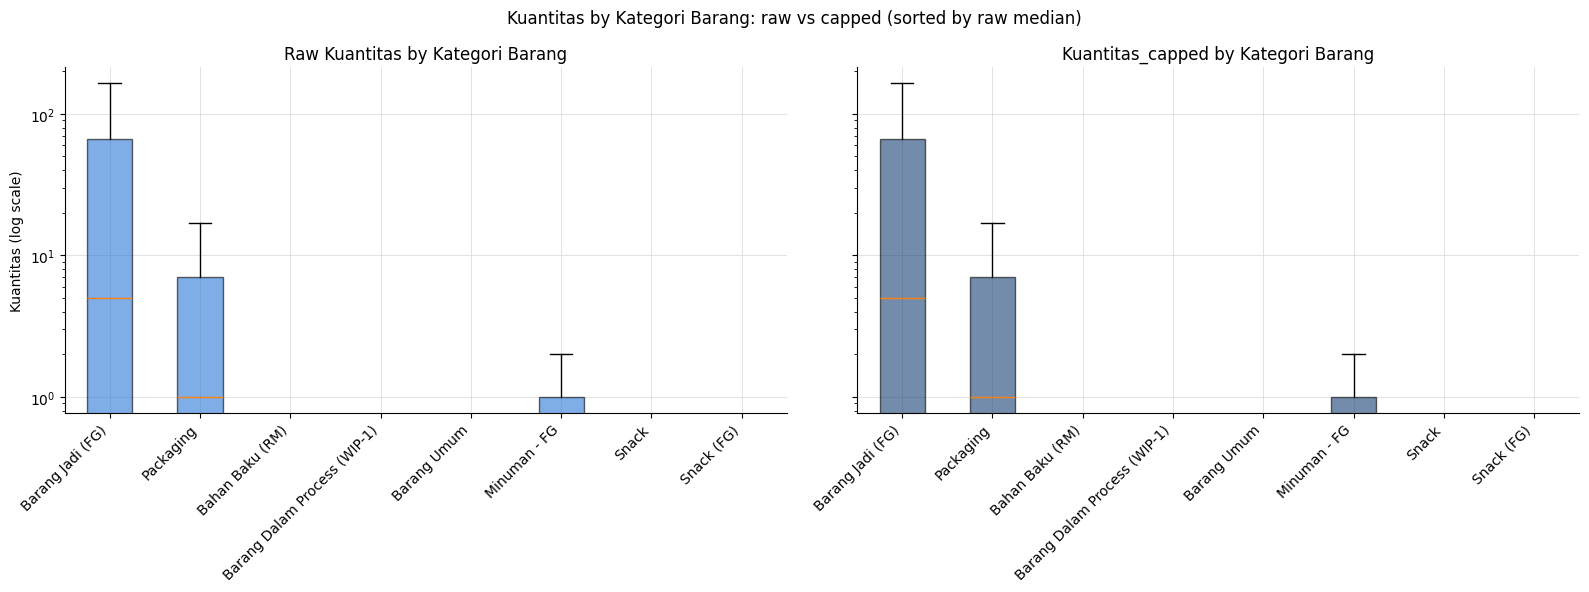

In [22]:
order = (
    featured.groupby("Kategori Barang", observed=True)["Kuantitas"]
    .median()
    .sort_values(ascending=False)
    .index
)
raw_by_cat = [featured.loc[featured["Kategori Barang"] == cat, "Kuantitas"] for cat in order]
capped_by_cat = [featured.loc[featured["Kategori Barang"] == cat, "Kuantitas_capped"] for cat in order]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

box_raw = axes[0].boxplot(raw_by_cat, tick_labels=list(order), patch_artist=True, showfliers=False)
for patch in box_raw["boxes"]:
    patch.set_facecolor(BLUE)
    patch.set_alpha(0.6)
axes[0].set_yscale("log")
axes[0].set_ylabel("Kuantitas (log scale)")
axes[0].set_title("Raw Kuantitas by Kategori Barang")
for label in axes[0].get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")

box_capped = axes[1].boxplot(capped_by_cat, tick_labels=list(order), patch_artist=True, showfliers=False)
for patch in box_capped["boxes"]:
    patch.set_facecolor(BLUE_DARK)
    patch.set_alpha(0.6)
axes[1].set_title("Kuantitas_capped by Kategori Barang")
for label in axes[1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")

fig.suptitle("Kuantitas by Kategori Barang: raw vs capped (sorted by raw median)")
plt.tight_layout()
plt.show()

In [23]:
prepare_forecast_data.export_featured(featured)
print(f"Wrote featured.parquet ({len(featured)} rows) to {prepare_forecast_data.MODEL_READY_DIR}")

Wrote featured.parquet (1340034 rows) to /Users/ramapdp/Project/Personal/forecast-scm/dataset/model_ready


---
Notebook ini berhenti di data yang sudah cleaned + feature-engineered (belum di-split) — sel di atas menulis hasilnya ke `dataset/model_ready/featured.parquet`. Cek dulu hasil tiap sel di atas (terutama 4 cek blocker yang masih terbuka: xxx. prefix, KY056 completeness, breakdown 842 pair, kategori time-varying), lalu lanjut ke `notebook/train_test_split.ipynb` untuk split train/test dan export ke `dataset/model_ready/{train,test}.parquet`.